In [12]:
%matplotlib inline

import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)


In [13]:
print("=" * 60)
print("LOADING PROCESSED DATA")
print("=" * 60)

df = pd.read_csv(
    PROCESSED_DIR / "order_line_with_inventory.csv",
    parse_dates=[
        "order_date",
        "order_time",
        "first_ship_out_time",
        "first_arr_station_time",
        "final_arrival_time",
        "first_order_month",
        "activate_date",
        "deactivate_date",
    ],
)
delivery_summary = pd.read_csv(
    PROCESSED_DIR / "delivery_summary.csv",
    parse_dates=["first_ship_out_time", "first_arr_station_time", "final_arrival_time"],
)

print(f"order_line_with_inventory: {df.shape}")
print(f"delivery_summary:          {delivery_summary.shape}")

df["product_type"] = pd.to_numeric(df["type_sku"], errors="coerce")
df["is_cross_dc"] = pd.to_numeric(df["remote_fulfillment_flag"], errors="coerce").fillna(0).astype(int)
df["inventory_at_dc_des"] = pd.to_numeric(df["inventory_at_dc_des"], errors="coerce").fillna(0).astype(int)
df["local_available_but_remote_shipped"] = (
    pd.to_numeric(df["local_available_but_remote_shipped"], errors="coerce").fillna(0).astype(int)
)

df["post_ship_delivery_hours"] = (
    df["final_arrival_time"] - df["first_ship_out_time"]
).dt.total_seconds() / 3600
df["promise_hours_proxy"] = pd.to_numeric(df["promise_days"], errors="coerce") * 24
df["fulfillment_gap_hours_proxy"] = df["hours_to_delivery"] - df["promise_hours_proxy"]
df["late_delivery_proxy"] = (
    df["fulfillment_gap_hours_proxy"] > 0
).where(df["fulfillment_gap_hours_proxy"].notna())

df_del = df.dropna(subset=["hours_to_delivery"]).copy()
df_del = df_del[df_del["hours_to_delivery"].between(0, 240)]

print(f"Missing hours_to_delivery:      {df['hours_to_delivery'].isna().sum():,}")
print(f"Missing post_ship_delivery:     {df['post_ship_delivery_hours'].isna().sum():,}")
print(f"Missing promise_hours_proxy:    {df['promise_hours_proxy'].isna().sum():,}")
print(f"JD-logged delivered order lines used for timing analysis: {len(df_del):,}")
print(
    "Metric note: use hours_to_delivery (order_time to final_arrival_time) as the main fulfillment metric."
)
print(
    "The older post_ship_delivery_hours metric is kept only as a secondary shipment-stage proxy."
)


LOADING PROCESSED DATA
order_line_with_inventory: (549989, 58)
delivery_summary:          (293204, 5)
Missing hours_to_delivery:      223,155
Missing post_ship_delivery:     223,155
Missing promise_hours_proxy:    208,583
JD-logged delivered order lines used for timing analysis: 326,238
Metric note: use hours_to_delivery (order_time to final_arrival_time) as the main fulfillment metric.
The older post_ship_delivery_hours metric is kept only as a secondary shipment-stage proxy.


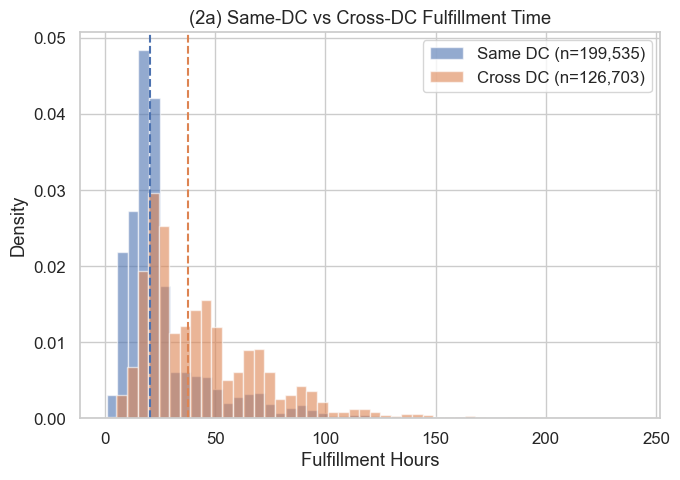


[2a] Cross-DC delays fulfillment?
  Same DC median = 20.4h, Cross DC median = 37.7h
  MWU test (same < cross): p = 0.0000e+00


In [14]:
# 2a. Cross-DC vs Same-DC fulfillment hours
fig, ax = plt.subplots(figsize=(7, 5))

cross = df_del[df_del["is_cross_dc"] == 1]["hours_to_delivery"]
same_dc = df_del[df_del["is_cross_dc"] == 0]["hours_to_delivery"]

ax.hist(same_dc, bins=50, alpha=0.6, color="#4C72B0", label=f"Same DC (n={len(same_dc):,})", density=True)
ax.hist(cross, bins=50, alpha=0.6, color="#DD8452", label=f"Cross DC (n={len(cross):,})", density=True)
ax.axvline(same_dc.median(), color="#4C72B0", linestyle="--", linewidth=1.5)
ax.axvline(cross.median(), color="#DD8452", linestyle="--", linewidth=1.5)
ax.set_xlabel("Fulfillment Hours")
ax.set_ylabel("Density")
ax.set_title("(2a) Same-DC vs Cross-DC Fulfillment Time")
ax.legend()

plt.tight_layout()
plt.show()

u_stat, u_p = stats.mannwhitneyu(same_dc, cross, alternative="less")
print(f"\n[2a] Cross-DC delays fulfillment?")
print(f"  Same DC median = {same_dc.median():.1f}h, Cross DC median = {cross.median():.1f}h")
print(f"  MWU test (same < cross): p = {u_p:.4e}")


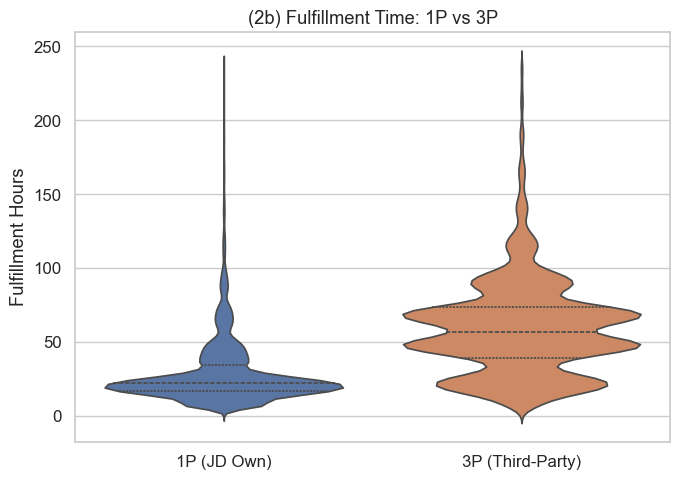


[2b] 1P vs 3P fulfillment hours
  1P median = 22.2h, 3P median = 56.6h
  MWU p = 0.0000e+00
  Caveat: comparison is conditional on JD-logged delivery records, not all 3P orders.


In [15]:
# 2b. 1P vs 3P fulfillment hours
fig, ax = plt.subplots(figsize=(7, 5))

df_del_typed = df_del[df_del["product_type"].isin([1, 2])].copy()
df_del_typed["product_label"] = df_del_typed["product_type"].map({1: "1P (JD Own)", 2: "3P (Third-Party)"})

sns.violinplot(
    data=df_del_typed,
    x="product_label",
    y="hours_to_delivery",
    palette={"1P (JD Own)": "#4C72B0", "3P (Third-Party)": "#DD8452"},
    inner="quartile",
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("Fulfillment Hours")
ax.set_title("(2b) Fulfillment Time: 1P vs 3P")

plt.tight_layout()
plt.show()

p1d = df_del_typed[df_del_typed["product_type"] == 1]["hours_to_delivery"]
p3d = df_del_typed[df_del_typed["product_type"] == 2]["hours_to_delivery"]
_, p_type = stats.mannwhitneyu(p1d, p3d, alternative="two-sided")
print(f"\n[2b] 1P vs 3P fulfillment hours")
print(f"  1P median = {p1d.median():.1f}h, 3P median = {p3d.median():.1f}h")
print(f"  MWU p = {p_type:.4e}")
print("  Caveat: comparison is conditional on JD-logged delivery records, not all 3P orders.")


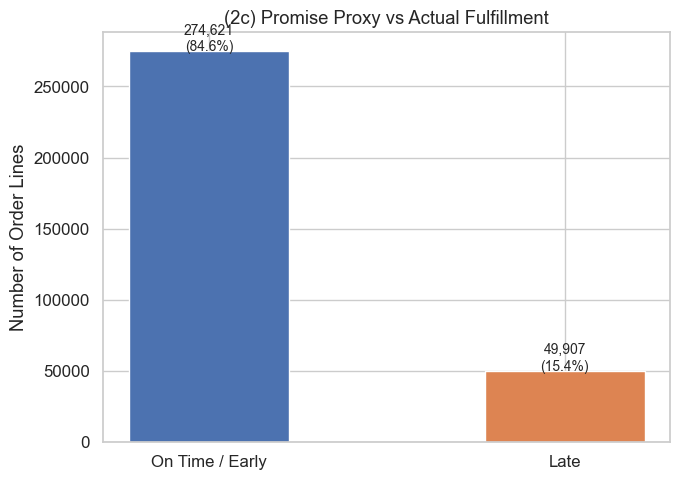


[2c] Promise proxy vs actual fulfillment
  Late-delivery proxy rate = 15.4%
  Mean fulfillment gap     = -10.8h
  Caveat: promise_days is a coarse day-level proxy and may not match the exact service promise clock.


In [16]:
# 2c. Promise proxy vs actual fulfillment hours
fig, ax = plt.subplots(figsize=(7, 5))

df_gap = df_del.dropna(subset=["promise_hours_proxy", "fulfillment_gap_hours_proxy"]).copy()
gap_counts = df_gap["late_delivery_proxy"].map({False: "On Time / Early", True: "Late"}).value_counts()
gap_counts = gap_counts.reindex(["On Time / Early", "Late"]).fillna(0)

ax.bar(gap_counts.index, gap_counts.values, color=["#4C72B0", "#DD8452"], edgecolor="white", width=0.45)
for i, v in enumerate(gap_counts.values):
    if gap_counts.sum() > 0:
        ax.text(i, v + 500, f"{int(v):,}\n({v / gap_counts.sum() * 100:.1f}%)", ha="center", fontsize=10)
ax.set_ylabel("Number of Order Lines")
ax.set_title("(2c) Promise Proxy vs Actual Fulfillment")

plt.tight_layout()
plt.show()

print(f"\n[2c] Promise proxy vs actual fulfillment")
print(f"  Late-delivery proxy rate = {df_gap['late_delivery_proxy'].mean() * 100:.1f}%")
print(f"  Mean fulfillment gap     = {df_gap['fulfillment_gap_hours_proxy'].mean():.1f}h")
print("  Caveat: promise_days is a coarse day-level proxy and may not match the exact service promise clock.")


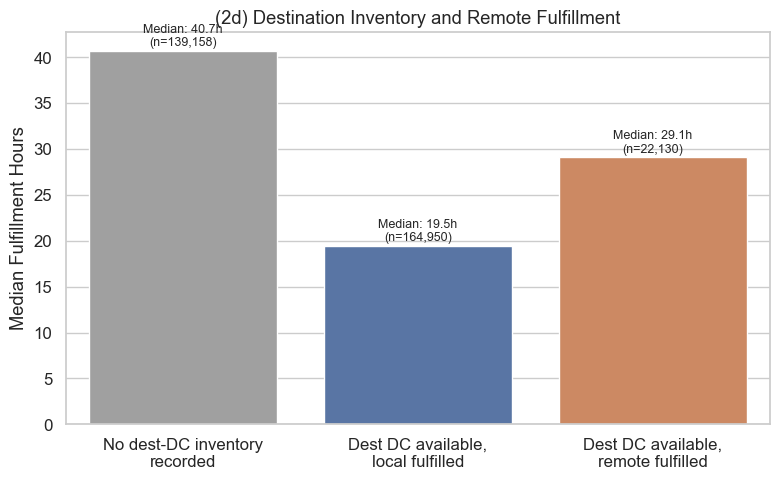


[2d] Destination inventory and remote fulfillment
  Dest inventory + local fulfillment median  = 19.5h
  Dest inventory + remote fulfillment median = 29.1h
  MWU test (local < remote): p = 0.0000e+00
  Caveat: inventory_at_dc_des reflects end-of-day availability records, not exact in-the-moment stock.


In [17]:
# 2d. Destination inventory and remote fulfillment
fig, ax = plt.subplots(figsize=(8, 5))

plot_df = df_del.copy()
plot_df["inventory_group"] = np.select(
    [
        plot_df["local_available_but_remote_shipped"] == 1,
        (plot_df["inventory_at_dc_des"] == 1) & (plot_df["is_cross_dc"] == 0),
    ],
    [
        "Dest DC available,\nremote fulfilled",
        "Dest DC available,\nlocal fulfilled",
    ],
    default="No dest-DC inventory\nrecorded",
)

group_order = [
    "No dest-DC inventory\nrecorded",
    "Dest DC available,\nlocal fulfilled",
    "Dest DC available,\nremote fulfilled",
]

inv_perf = (
    plot_df.groupby("inventory_group")["hours_to_delivery"]
    .agg(["median", "mean", "count"])
    .reindex(group_order)
    .reset_index()
)

sns.barplot(
    data=inv_perf,
    x="inventory_group",
    y="median",
    hue="inventory_group",
    palette={
        "No dest-DC inventory\nrecorded": "#A0A0A0",
        "Dest DC available,\nlocal fulfilled": "#4C72B0",
        "Dest DC available,\nremote fulfilled": "#DD8452",
    },
    dodge=False,
    ax=ax,
)
if ax.legend_ is not None:
    ax.legend_.remove()
for _, row in inv_perf.iterrows():
    ax.text(
        row["inventory_group"],
        row["median"] + 0.5,
        f"Median: {row['median']:.1f}h\n(n={int(row['count']):,})",
        ha="center",
        fontsize=9,
    )
ax.set_xlabel("")
ax.set_ylabel("Median Fulfillment Hours")
ax.set_title("(2d) Destination Inventory and Remote Fulfillment")

plt.tight_layout()
plt.show()

local_avail_local = plot_df[(plot_df["inventory_at_dc_des"] == 1) & (plot_df["is_cross_dc"] == 0)]["hours_to_delivery"]
local_avail_remote = plot_df[plot_df["local_available_but_remote_shipped"] == 1]["hours_to_delivery"]
if len(local_avail_local) > 0 and len(local_avail_remote) > 0:
    _, p_remote = stats.mannwhitneyu(local_avail_local, local_avail_remote, alternative="less")
    print(f"\n[2d] Destination inventory and remote fulfillment")
    print(f"  Dest inventory + local fulfillment median  = {local_avail_local.median():.1f}h")
    print(f"  Dest inventory + remote fulfillment median = {local_avail_remote.median():.1f}h")
    print(f"  MWU test (local < remote): p = {p_remote:.4e}")
print("  Caveat: inventory_at_dc_des reflects end-of-day availability records, not exact in-the-moment stock.")
